In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import RidgeClassifier, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, GradientBoostingClassifier, VotingClassifier, BaggingClassifier 
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("prepered_sleep.csv")
data.head()

,Gender,Age,Occupation,BMI Category,Heart Rate,Sleep Disorder,Blood Pressure Sist,Peace Level,Activity
0,0,27,Software Engineer,Overweight,77,0,126,6.10,176400
1,0,28,Doctor,Normal,75,0,125,4.65,600000
2,0,28,Doctor,Normal,75,0,125,4.65,600000
3,0,28,Sales Representative,Obese,85,2,140,2.95,90000
4,0,28,Sales Representative,Obese,85,2,140,2.95,90000


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Gender               374 non-null    int64  
 1   Age                  374 non-null    int64  
 2   Occupation           374 non-null    object 
 3   BMI Category         374 non-null    object 
 4   Heart Rate           374 non-null    int64  
 5   Sleep Disorder       374 non-null    int64  
 6   Blood Pressure Sist  374 non-null    int64  
 7   Peace Level          374 non-null    float64
 8   Activity             374 non-null    int64  
dtypes: float64(1), int64(6), object(2)
memory usage: 26.4+ KB


In [4]:
X = data.drop(columns = ["Sleep Disorder"])
y = data["Sleep Disorder"]

In [5]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 100, stratify=y)

In [6]:
categories = [["Normal", "Overweight", "Obese"]]
oe_BMI = OrdinalEncoder(categories = categories)
x_train["BMI Category"] = oe_BMI.fit_transform(x_train[["BMI Category"]])
x_test["BMI Category"] = oe_BMI.transform(x_test[["BMI Category"]])

In [7]:
ohe_job = OneHotEncoder(sparse_output = False, handle_unknown='ignore', 
                        categories = [list(x_train["Occupation"].value_counts().index[:7])])
occupation = ohe_job.fit_transform(x_train[["Occupation"]])
columns_name = ohe_job.get_feature_names_out()
x_train = x_train.join(pd.DataFrame(occupation, columns = columns_name, index = x_train.index)).drop(columns = "Occupation")
x_test = x_test.join(pd.DataFrame(ohe_job.transform(x_test[["Occupation"]]), columns = columns_name, index = x_test.index)).drop(columns = "Occupation")

In [8]:
ss = StandardScaler()
ss.fit(x_train)
x_train = pd.DataFrame(ss.transform(x_train), columns = x_train.columns, index = x_train.index)
x_test = pd.DataFrame(ss.transform(x_test), columns = x_test.columns, index = x_test.index)

In [9]:
model_score = pd.DataFrame(np.zeros((6, 4)), 
                           index = ["Random Forest", "Gradient Boosting", 
                                    "XGBoost", "Stacking",
                                    "Voting", "Bagging"],
                           columns = ["Train_Macro", "Train_Micro", "Test_Macro", "Test_Micro"])

In [10]:
p1 = Pipeline([("model", RandomForestClassifier())])

p2 = Pipeline([("model", GradientBoostingClassifier(max_features = 'sqrt'))])

p3 = Pipeline([("model", XGBClassifier())])

p4 = Pipeline([("model", StackingClassifier([("logistic", LogisticRegression()), 
                                             ("neighbors", KNeighborsClassifier()), ("tree", DecisionTreeClassifier())]))])

p5 = Pipeline([("model", VotingClassifier(
    [("logistic", LogisticRegression()), ("neighbors", KNeighborsClassifier()), ("tree", DecisionTreeClassifier())]))])

p6 = Pipeline([("model", BaggingClassifier())])

models = [p1, p2, p3, p4, p5, p6]

for i, p in enumerate(models):
    p.fit(x_train, y_train)
    pred_train = p.predict(x_train)
    pred_test = p.predict(x_test)
    model_score.iloc[i] = [f1_score(y_train, pred_train, average = "macro"), f1_score(y_train, pred_train, average = "micro"),
                                                  f1_score(y_test, pred_test, average = "macro"), f1_score(y_test, pred_test, average = "micro")]


In [11]:
model_score

,Train_Macro,Train_Micro,Test_Macro,Test_Micro
Random Forest,0.913131,0.931034,0.882751,0.902655
Gradient Boosting,0.912859,0.931034,0.882751,0.902655
XGBoost,0.913131,0.931034,0.882751,0.902655
Stacking,0.906676,0.927203,0.882751,0.902655
Voting,0.907121,0.927203,0.882751,0.902655
Bagging,0.913350,0.931034,0.910502,0.920354


In [12]:
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [10, 20, None],
    'model__min_samples_split': [2, 5, 10],
    'model__ccp_alpha': [0, 0.001, 0.01, 0.1]
}
gs_random_forest = GridSearchCV(p1, param_grid, cv = 3, scoring = "f1_macro")
gs_random_forest.fit(x_train, y_train)
gs_random_forest.best_params_, gs_random_forest.best_score_

({'model__ccp_alpha': 0.01,
  'model__max_depth': 10,
  'model__min_samples_split': 5,
  'model__n_estimators': 200},
 np.float64(0.8872105433590106))

In [13]:
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5],
    'model__subsample': [0.8, 1.0],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
}
gs_gradient_boost = GridSearchCV(p2, param_grid, cv = 3, scoring = "f1_macro")
gs_gradient_boost.fit(x_train, y_train)
gs_gradient_boost.best_params_, gs_gradient_boost.best_score_

({'model__learning_rate': 0.01,
  'model__max_depth': 3,
  'model__n_estimators': 200,
  'model__subsample': 1.0},
 np.float64(0.8803178231019974))

In [14]:
par = param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5],
    'model__subsample': [0.8, 1.0],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
}
gs_XGBoost = GridSearchCV(p3, par, cv = 3, scoring = "f1_macro")
gs_XGBoost.fit(x_train, y_train)
gs_XGBoost.best_params_, gs_XGBoost.best_score_

({'model__learning_rate': 0.01,
  'model__max_depth': 3,
  'model__n_estimators': 200,
  'model__subsample': 0.8},
 np.float64(0.8860255099159126))

In [15]:
var = np.concat([np.logspace(-2, 2, 20), [1.0]])

In [16]:
par = {"C": var}
gs_logistic = GridSearchCV(LogisticRegression(max_iter=1000), par, cv = 3, scoring = "f1_macro")
gs_logistic.fit(x_train, y_train)

par = {"n_neighbors": list(range(1, 20)),
      'weights': ['uniform', 'distance'],
      'p': [1, 2]}
gs_neighbors = GridSearchCV(KNeighborsClassifier(), par, cv = 3, scoring = "f1_macro")
gs_neighbors.fit(x_train, y_train)

par = {"criterion": ["gini", "entropy"],
       "max_depth": [5, 7, 10, 13, 15, None],
       "max_features": ['sqrt', 'log2', 0.5, None],
       "min_samples_leaf": [1, 3, 5, 7, 10, 15],
       "min_samples_split": [2, 5, 10, 15, 20],
       "class_weight": [None, 'balanced'],
       "splitter": ['best', 'random']}

gs_tree = GridSearchCV(DecisionTreeClassifier(), par, cv = 3, scoring = "f1_macro")
gs_tree.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': [None, 'balanced'], 'criterion': ['gini', 'entropy'], 'max_depth': [5, 7, ...], 'max_features': ['sqrt', 'log2', ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each

In [17]:
par = {'final_estimator': [LogisticRegression(), LogisticRegression(C=0.1), LogisticRegression(C=10), RandomForestClassifier()],
       'stack_method': ['predict_proba', 'predict'],
       'passthrough': [False, True]
      }
gs_stack = GridSearchCV(StackingClassifier([("logistic", LogisticRegression(**gs_logistic.best_params_)), 
                                            ("neighbors", KNeighborsClassifier(**gs_neighbors.best_params_)), 
                                            ("tree", DecisionTreeClassifier(**gs_tree.best_params_))]), par, cv = 3, scoring = "f1_macro")
gs_stack.fit(x_train, y_train)
gs_stack.best_params_, gs_stack.best_score_

({'final_estimator': RandomForestClassifier(),
  'passthrough': False,
  'stack_method': 'predict_proba'},
 np.float64(0.8907534918835219))

In [18]:
par = {'voting': ['hard', 'soft']}
gs_vote = GridSearchCV(VotingClassifier([("logistic", LogisticRegression(**gs_logistic.best_params_)), 
                                          ("neighbors", KNeighborsClassifier(**gs_neighbors.best_params_)), 
                                          ("tree", DecisionTreeClassifier(**gs_tree.best_params_))]), par, cv = 3, scoring = "f1_macro")
gs_vote.fit(x_train, y_train)
gs_vote.best_params_, gs_vote.best_score_

({'voting': 'hard'}, np.float64(0.866177658408513))

In [19]:
par = {"model__estimator": [LogisticRegression(**gs_logistic.best_params_), 
                            KNeighborsClassifier(**gs_neighbors.best_params_), 
                            DecisionTreeClassifier(**gs_tree.best_params_)],
       'model__n_estimators':  [10, 50, 100, 200],
       'model__max_samples': [0.5, 0.7, 1.0],
       'model__max_features': [0.5, 0.7, 1.0]}

gs_Bagging = GridSearchCV(p6, par, cv = 3, scoring = "f1_macro")
gs_Bagging.fit(x_train, y_train)
gs_Bagging.best_params_, gs_Bagging.best_score_

({'model__estimator': LogisticRegression(C=np.float64(0.4832930238571752)),
  'model__max_features': 0.7,
  'model__max_samples': 0.5,
  'model__n_estimators': 10},
 np.float64(0.8833696441539579))

In [20]:
model_score_upgraded = pd.DataFrame(np.zeros((6, 4)), 
                                    index = ["Random Forest", "Gradient Boosting", "XGBoost", "Stacking", "Voting", "Bagging"],
                                    columns = ["Train_Macro", "Train_Micro", "Test_Macro", "Test_Micro"])

In [21]:
p7 = Pipeline([("model", RandomForestClassifier(ccp_alpha = gs_random_forest.best_params_["model__ccp_alpha"], 
                                                max_depth = gs_random_forest.best_params_["model__max_depth"],
                                                min_samples_split = gs_random_forest.best_params_["model__min_samples_split"], 
                                                n_estimators = gs_random_forest.best_params_["model__n_estimators"]))])

p8 = Pipeline([("model", GradientBoostingClassifier(max_features = 'sqrt',
                                                    n_estimators = gs_gradient_boost.best_params_['model__n_estimators'],
                                                    max_depth = gs_gradient_boost.best_params_['model__max_depth'],
                                                    subsample = gs_gradient_boost.best_params_['model__subsample'],
                                                    learning_rate = gs_gradient_boost.best_params_['model__learning_rate']))])

p9 = Pipeline([("model", XGBClassifier(n_estimators = gs_XGBoost.best_params_['model__n_estimators'],
                                        max_depth = gs_XGBoost.best_params_['model__max_depth'],
                                        subsample = gs_XGBoost.best_params_['model__subsample'],
                                        learning_rate = gs_XGBoost.best_params_['model__learning_rate']))])

p10 = Pipeline([("model", StackingClassifier([("logistic", LogisticRegression(**gs_logistic.best_params_)), 
                                            ("neighbors", KNeighborsClassifier(**gs_neighbors.best_params_)), 
                                            ("tree", DecisionTreeClassifier(**gs_tree.best_params_))], **gs_stack.best_params_))])

p11 = Pipeline([("model", VotingClassifier([("logistic", LogisticRegression(**gs_logistic.best_params_)), 
                                          ("neighbors", KNeighborsClassifier(**gs_neighbors.best_params_)), 
                                          ("tree", DecisionTreeClassifier(**gs_tree.best_params_))], 
                                           **gs_vote.best_params_))])

p12 = Pipeline([("model", BaggingClassifier(estimator = gs_Bagging.best_params_["model__estimator"],
                                            n_estimators = gs_Bagging.best_params_["model__n_estimators"],
                                            max_samples = gs_Bagging.best_params_["model__max_samples"],
                                            max_features = gs_Bagging.best_params_["model__max_features"]))])

upgraded_models = [p7, p8, p9, p10, p11, p12]

for i, p in enumerate(upgraded_models):
    p.fit(x_train, y_train)
    pred_train = p.predict(x_train)
    pred_test = p.predict(x_test)
    model_score_upgraded.iloc[i] = [f1_score(y_train, pred_train, average = "macro"), f1_score(y_train, pred_train, average = "micro"),
                                    f1_score(y_test, pred_test, average = "macro"), f1_score(y_test, pred_test, average = "micro")]

In [22]:
model_score

,Train_Macro,Train_Micro,Test_Macro,Test_Micro
Random Forest,0.913131,0.931034,0.882751,0.902655
Gradient Boosting,0.912859,0.931034,0.882751,0.902655
XGBoost,0.913131,0.931034,0.882751,0.902655
Stacking,0.906676,0.927203,0.882751,0.902655
Voting,0.907121,0.927203,0.882751,0.902655
Bagging,0.913350,0.931034,0.910502,0.920354


In [23]:
model_score_upgraded

,Train_Macro,Train_Micro,Test_Macro,Test_Micro
Random Forest,0.906676,0.927203,0.882751,0.902655
Gradient Boosting,0.913131,0.931034,0.882751,0.902655
XGBoost,0.906927,0.927203,0.882751,0.902655
Stacking,0.902831,0.923372,0.882751,0.902655
Voting,0.903720,0.923372,0.882751,0.902655
Bagging,0.880006,0.904215,0.882751,0.902655


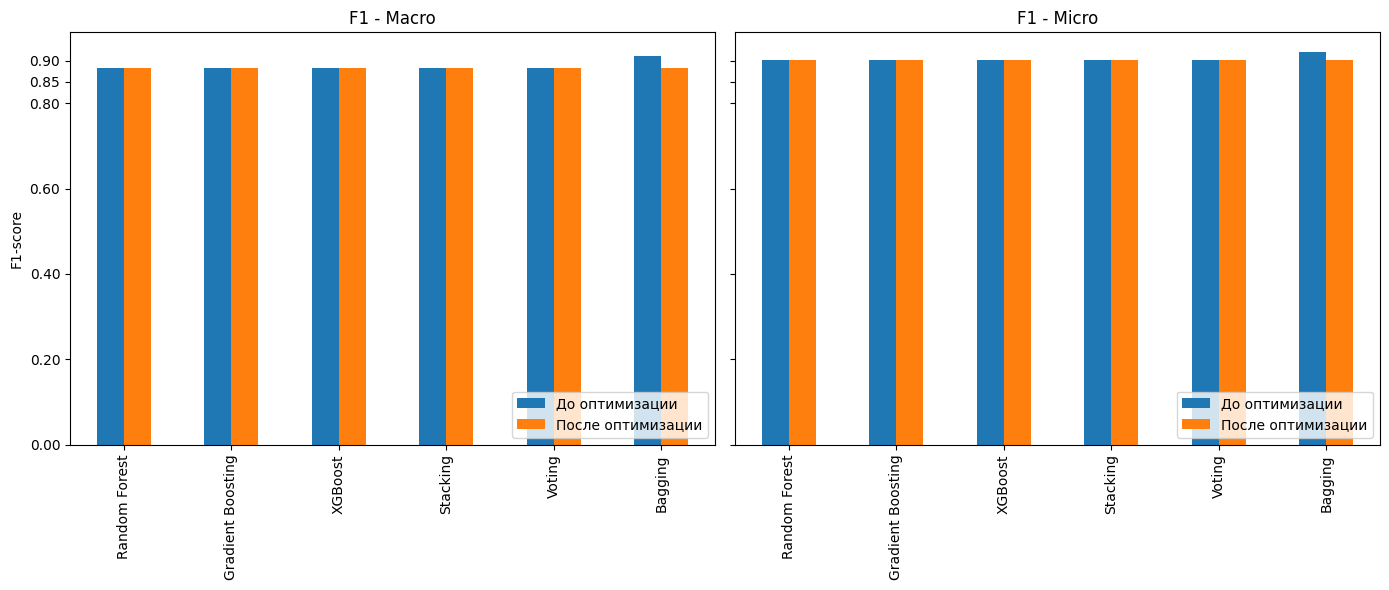

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey = True)

pd.concat([model_score['Test_Macro'], model_score_upgraded['Test_Macro']], axis = 1, keys = ['До оптимизации', 'После оптимизации']).plot(
    kind='bar', ax=axes[0], title='F1 - Macro'
)
axes[0].set_ylabel('F1-score')
axes[0].legend(loc='lower right')
axes[0].set_yticks(np.append(axes[0].get_yticks(), [0.85, 0.9]))

pd.concat([model_score['Test_Micro'], model_score_upgraded['Test_Micro']], axis = 1, keys = ['До оптимизации', 'После оптимизации']).plot(
    kind='bar', ax=axes[1], title='F1 - Micro'
)
axes[1].set_ylabel('F1-score')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

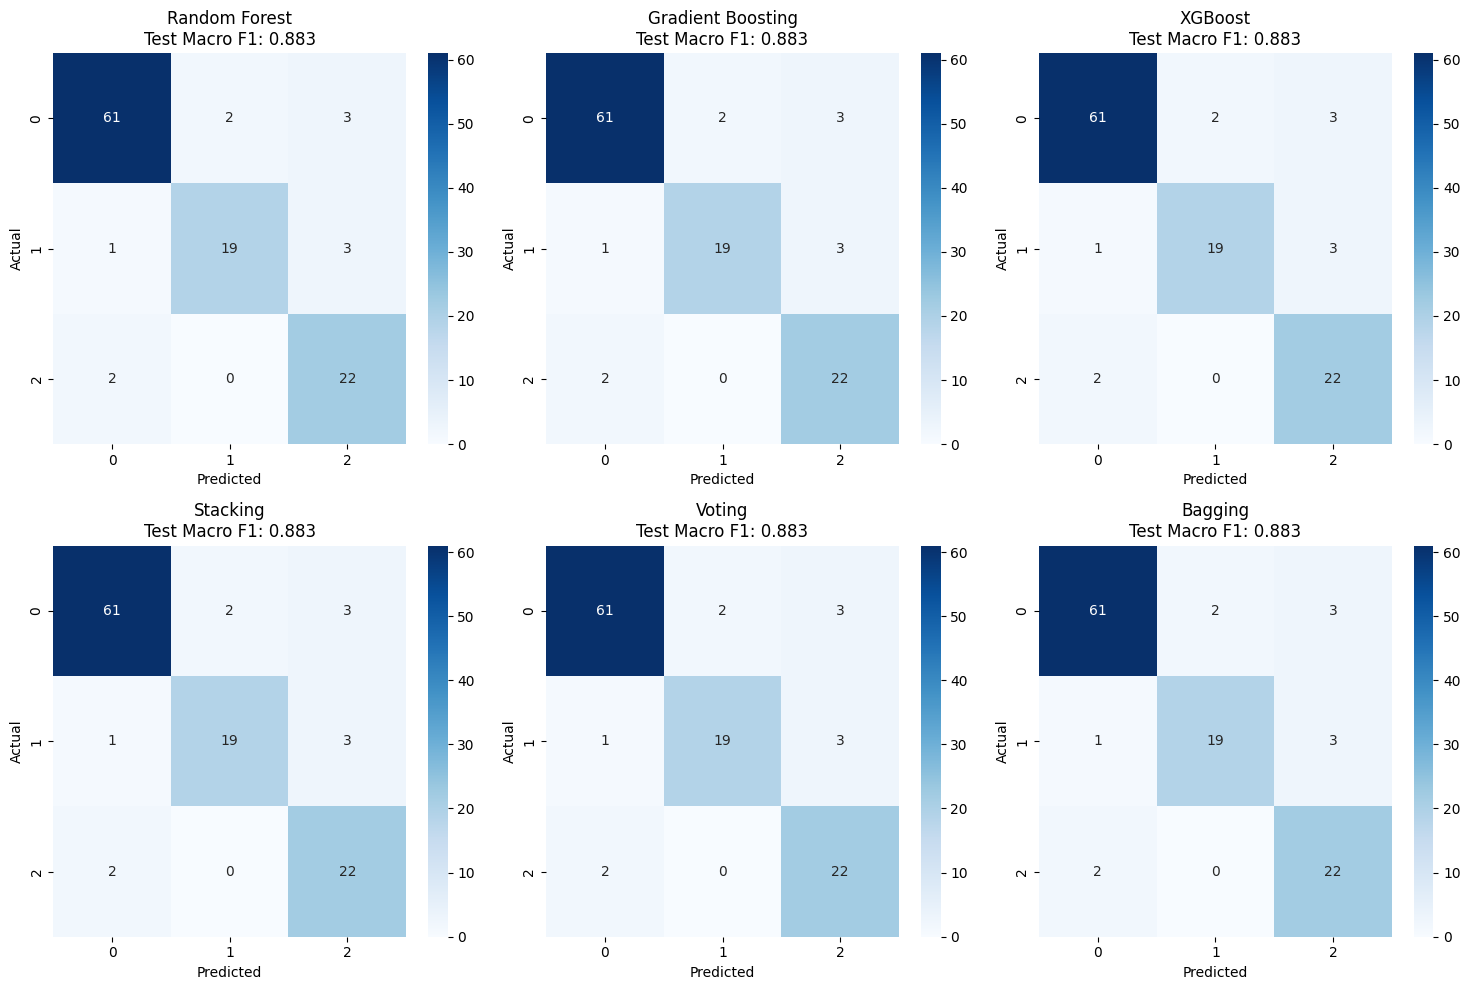

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, (name, model) in enumerate(zip(model_score_upgraded.index, upgraded_models)):
    cm = confusion_matrix(y_test, model.predict(x_test))
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx], cmap='Blues')
    axes[idx].set_title(f'{name}\nTest Macro F1: {model_score_upgraded.iloc[idx, 2]:.3f}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()